# Ejercicios Prácticos - Algoritmos de regresión

##### II DIPLOMA DE EXPERTO EN APRENDIZAJE AUTOMÁTICO AVANZADO EN PYTHON
#### Alumno: Pablo Fazio Arrabal

---

## Ejercicios Básicos

1. Cargue el conjunto de muestras “RealEstate.xlsx”, seleccione los rasgos que considere oportunos y realice un análisis del conjunto de datos tal y como hemos visto en la práctica, es decir:

    **a)** Dibuje las gráficas que relacionan los pares de rasgos. Comente los resultados.

    **b)** Dibuje la matriz de correlación. ¿Qué atributo es más prometedor para realizar una regresión lineal? ¿Cuál es menos prometedor en este sentido? Razone su respuesta.

    **c)** Escale los rasgos y realice una regresión lineal simple con el atributo más prometedor. ¿Obtiene un resultado adecuado? Razone su respuesta.

    **d)** Elija un valor sin escalar del rasgo seleccionado en el apartado anterior y calcule el precio estimado para dicho valor.

    *Nota: Si lo desea, ayúdese del método siguiente para cargar las muestras:*
    ```
    pd.read_excel('nombre.xlsx', index_col=None, header=0,
    names=nombresColumnas)
    ```



In [1]:
# En primer lugar, cargamos las muestras como se indica en el enunciado

import pandas as pd

# Definimos los nombres de las columnas en el conjunto

nombresColumnas = ['number', 'transaction_date', 'house_age', 'dst_near_MRT', 'num_store',
                   'latitude', 'longitude', 'house_price_unit_area']

df = pd.read_excel('RealEstate.xlsx', index_col=None, header=0, names=nombresColumnas)

df

,number,transaction_date,house_age,dst_near_MRT,num_store,latitude,longitude,house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.666667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250000,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000000,8.1,104.81010,5,24.96674,121.54067,52.5


In [2]:
# Voy a elegir para hacer el análisis todas las columnas salvo la del número
# de transacción que es irrelevante

colElegidas = ['transaction_date', 'house_age', 'dst_near_MRT', 'num_store',
              'latitude', 'longitude', 'house_price_unit_area']

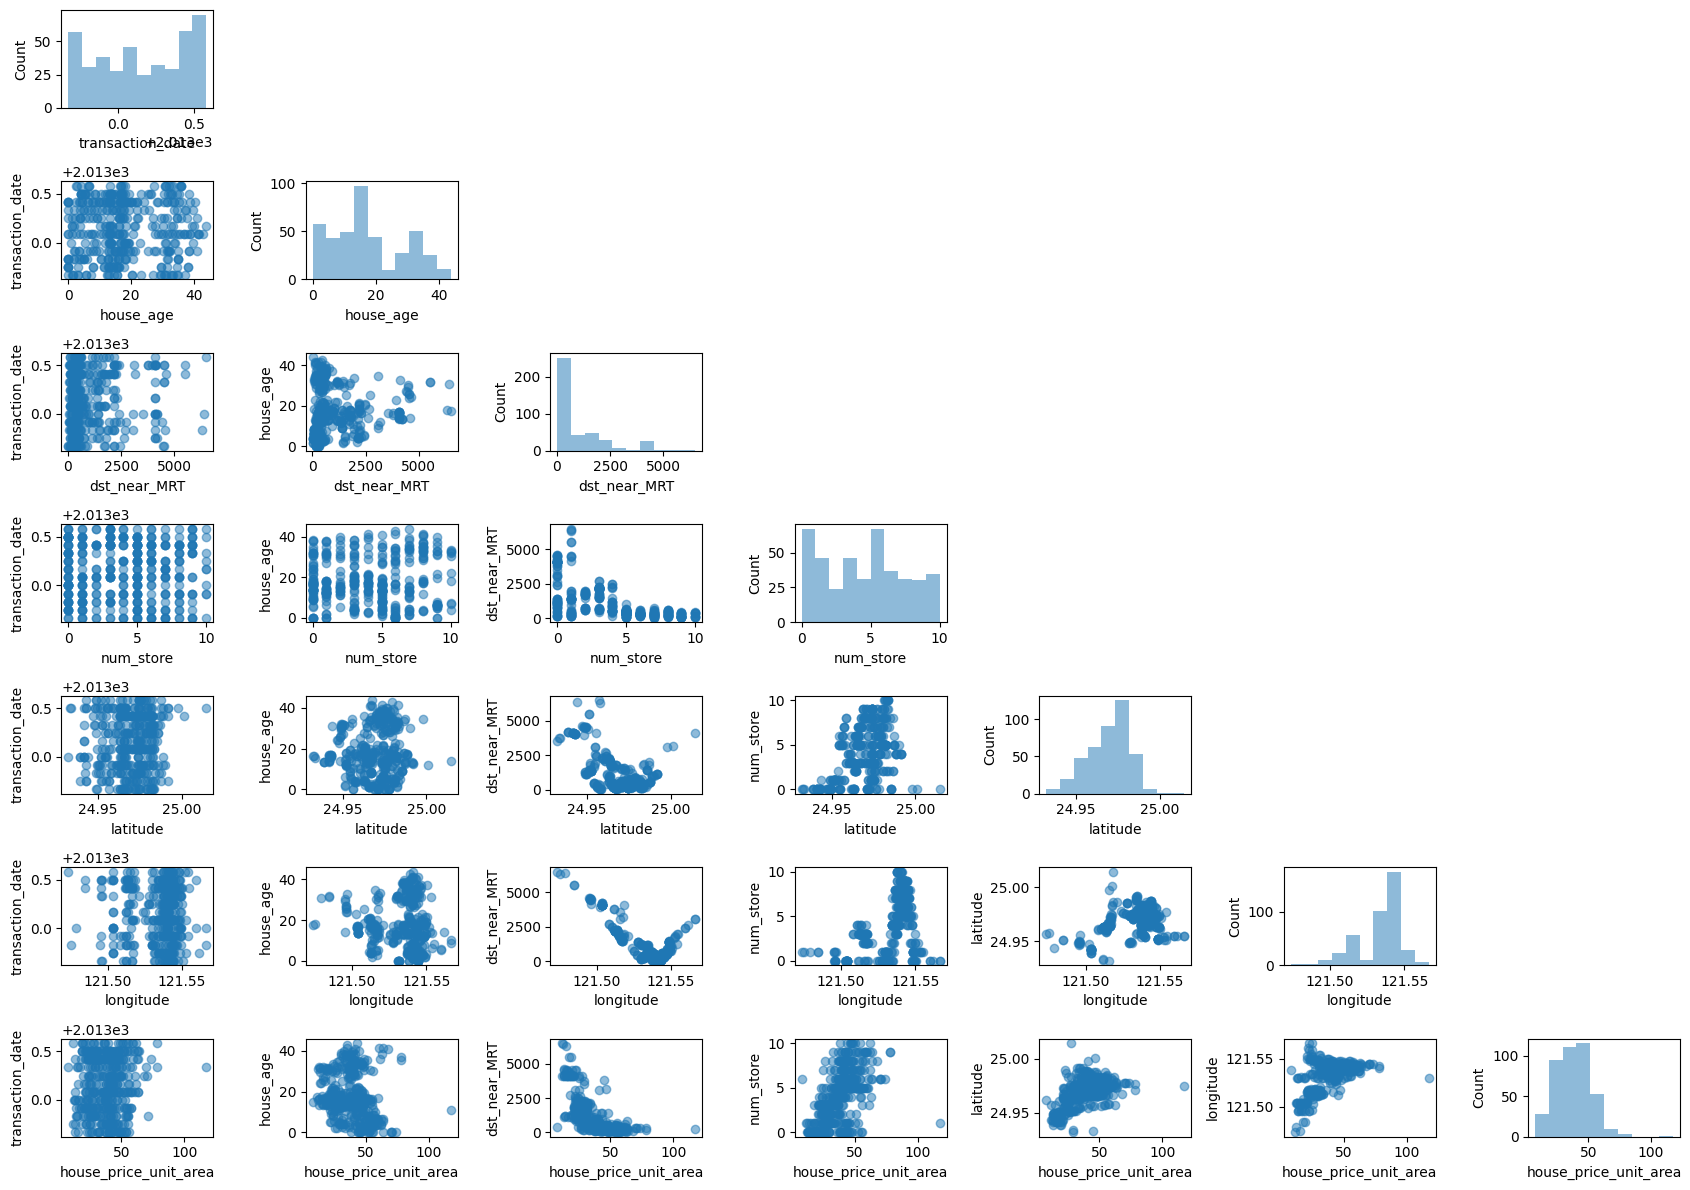

In [3]:
# APARTADO A)

import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

# Dibujamos la gráfica que relaciona todos los pares de rasgos

scatterplotmatrix(df[colElegidas].values, figsize=(17, 12),
                   names=colElegidas, alpha=0.5)
plt.tight_layout()
plt.show()

##### **Algunos comentarios sobre la gráfica anterior**

*   Todas las variables son continuas salvo '*num_store*' que toma valores discretos.
*   La mayoría de precios por unidad de área se encuentran en el rango de 50, no sobrepasando nunca los 100.
*   En la gran mayoría de casos, la distancia a la estación de metro más cercana es muy baja.
*   Hay una fuerte relación entre la distancia al metro más cercano y la longitud (posición) de la casa.
*   El precio se relaciona mucho con la distancia al metro más cercano y con el número de tiendas cercanas.  


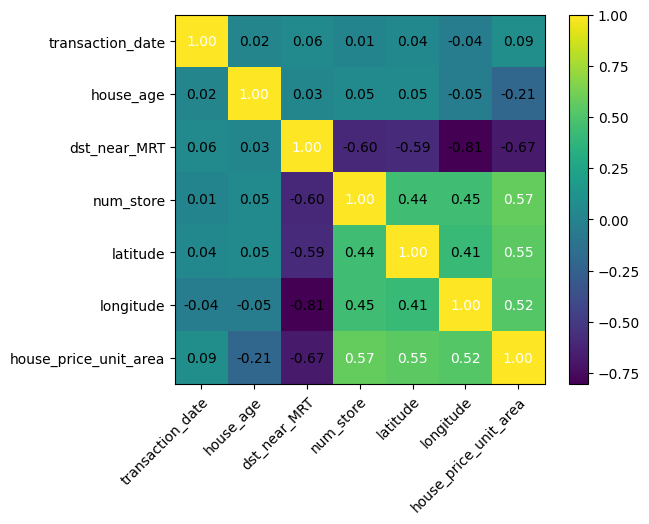

In [4]:
# APARTADO B)

from mlxtend.plotting import heatmap
import numpy as np

# Dibujamos la matriz de correlación como hemos visto en la práctica guiada

matrizCorr = np.corrcoef(df[colElegidas].values.T)
mapaCalor = heatmap(matrizCorr, row_names=colElegidas, column_names=colElegidas)
plt.show()

El atributo más prometedor para realizar una regresión lineal es ***'dst_near_MRT'*** (distancia a la estación de MRT más cercana). Esto es debido a que posee una gran correlación inversa con el atributo de clase '*house_price_unit_area*'.

El atributo menos prometedor será '***transaction_date***' (fecha de transacción). Ya que la correlación es mínima con el atributo de clase.

In [5]:
# APARTADO C)

from sklearn.preprocessing import StandardScaler

# Preparamos muestras
X = df[['dst_near_MRT']].values
y = df['house_price_unit_area'].values

# Estandarizamos rasgos y salida deseada como en la práctica
xEstandarizador = StandardScaler()
yEstandarizador = StandardScaler()
X_est = xEstandarizador.fit_transform(X)

# Estandarizamos valores objetivo, aplicamos función flatten para pasar a
# vector de una dimensión

y_est = yEstandarizador.fit_transform(y[:, np.newaxis]).flatten()

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

regLin = LinearRegression()
regLin.fit(X_est, y_est)

# Calculamos el ECM final
y_pred_est = regLin.predict(X_est)
ecm_final = mean_squared_error(y_est, y_pred_est)
print(f"ECM Final: {ecm_final}")

ECM Final: 0.546245721081733


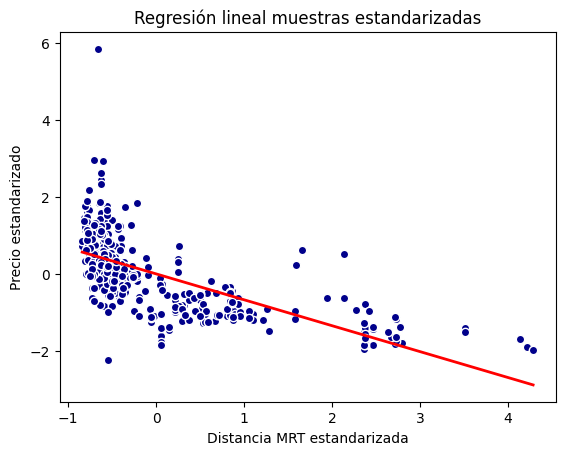

In [7]:
plt.scatter(X_est, y_est, c='darkblue', edgecolor='white')

# Dibujamos la recta de regresión
XInicioFinRectaReg = np.array([X_est.min(), X_est.max()])
YInicioFinRectaReg = regLin.predict(XInicioFinRectaReg[:, np.newaxis])
plt.plot(XInicioFinRectaReg, YInicioFinRectaReg, color='red', lw=2)

plt.title('Regresión lineal muestras estandarizadas')
plt.xlabel('Distancia MRT estandarizada')
plt.ylabel('Precio estandarizado')
plt.show()

En principio, obtenemos una regresión lineal para el atributo correcta, aunque es cierto que no conseguimos mejorar el ECM de 0.55 (que es ciertamente un valor alto).

Esto es debido a la gran cantidad de muestras que se acumulan en la distancia a la estación MRT más cercana que son iguales a 0.

In [8]:
# APARTADO D)

# Vamos a tomar por ejemplo el valor de 723 metros
distancia_mrt = 723

# Calculamos el precio estimado para dicho valor mostrando el resultado sin escalar
distanciaMRTEst = xEstandarizador.transform(np.array([[distancia_mrt]]))
precioEst = regLin.predict(distanciaMRTEst)
print("El precio estimado por unidad de área para una casa cuya estación MRT más cercana está a %.3f metros es: %.3f"%
      (distancia_mrt, yEstandarizador.inverse_transform(precioEst.reshape(-1,1))[0,0]))

El precio estimado por unidad de área para una casa cuya estación MRT más cercana está a 723.000 metros es: 40.601


2. Divida el conjunto de muestras “RealState.xlsx” en entrenamiento y test:

    **a)** Utilice únicamente el conjunto de entrenamiento para entrenar mediante RANSAC una recta de regresión con el rasgo más prometedor del ejercicio anterior. Ajuste los hiperparámetros de RANSAC para que al menos haya 20 muestras seleccionadas durante el entrenamiento, es decir, que no sean atípicas.

    **b)** Dibuje la recta de regresión resultante donde se observen las muestras típicas y las atípicas del conjunto de entrenamiento en colores diferentes.

    **c)** Ahora considere tanto el conjunto de entrenamiento como el de test y dibuje la nube de residuos correspondiente para ambos conjuntos.

    **d)** Observando la nube de residuos, ¿qué rango de valores predichos suelen ser más fiables en este modelo?

    **e)** Calcule el ECM y el coeficiente de determinación del modelo en entrenamiento y en test.

In [9]:
# División del conjunto de muestras en entrenamiento y test como ya
# venimos haciendo en el resto de prácticas

from sklearn.model_selection import train_test_split

X_ent, X_test, y_ent, y_test = train_test_split(X, y, test_size=0.3,
                                                random_state=0)

In [10]:
# APARTADO A)

from sklearn.linear_model import RANSACRegressor

# Creamos y entrenamos objeto RANSAC
# Modificamos el residual_threshold de forma que seamos más admisivos y haya
# un mayor número de muestras no atípicas

ransac = RANSACRegressor(LinearRegression(), max_trials=150, min_samples=50,
                          loss='absolute_error', residual_threshold=0.5,
                          random_state=0)
ransac.fit(X_ent, y_ent)

# Apuntamos las muestras típicas y atípicas
mascaraMuestrasTípicas = ransac.inlier_mask_
mascaraMuestrasAtípicas = np.logical_not(mascaraMuestrasTípicas)

# Debemos asegurarnos que haya al menos 20 muestras seleccionadas durante el
# entrenamiento
num_tipicas = mascaraMuestrasTípicas.sum()
print(f"Número de muestras típicas: {num_tipicas}")

Número de muestras típicas: 25


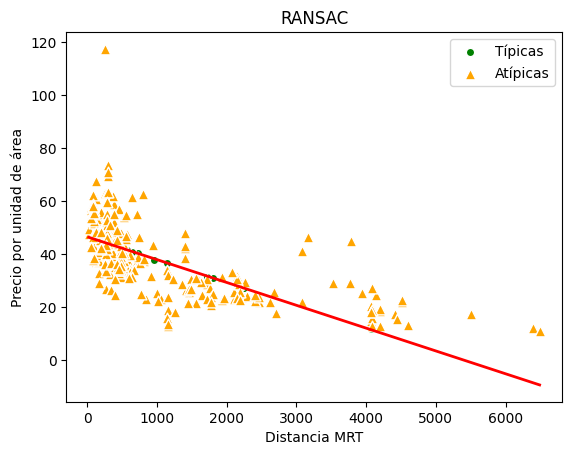

In [11]:
# APARTADO B)

# Una vez que obtenemos el número suficiente de muestras, pintamos
# las muestras típicas y atípicas en la gráfica en colores distintos

plt.scatter(X_ent[mascaraMuestrasTípicas], y_ent[mascaraMuestrasTípicas],
             c='green', edgecolor='white',
             marker='o', label='Típicas')
plt.scatter(X_ent[mascaraMuestrasAtípicas], y_ent[mascaraMuestrasAtípicas],
             c='orange', edgecolor='white',
             marker='^', label='Atípicas', s=60)

# Pintamos recta de regresión

XInicioFinRectaRANSAC = np.array([X_ent.min()-1, X_ent.max()+1])
yInicioFinRectaRANSAC = ransac.predict(XInicioFinRectaRANSAC[:, np.newaxis])
plt.plot(XInicioFinRectaRANSAC, yInicioFinRectaRANSAC, color='red', lw=2)

plt.title('RANSAC')
plt.xlabel('Distancia MRT')
plt.ylabel('Precio por unidad de área')
plt.legend(loc='best')
plt.show()

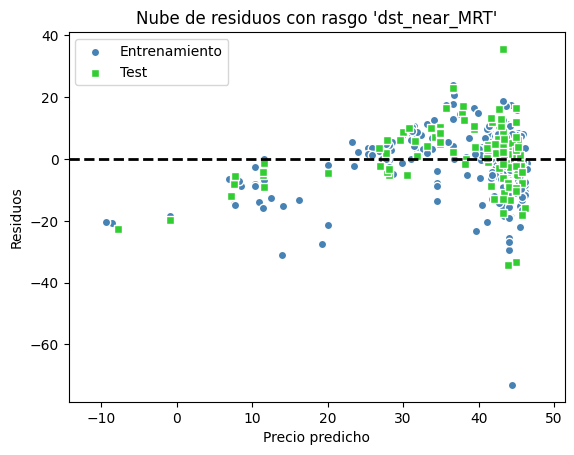

In [12]:
# APARTADO C)

y_ent_pred = ransac.predict(X_ent)
y_test_pred = ransac.predict(X_test)

# Graficamos la nube de residuos tanto para entrenamiento como para test

plt.scatter(y_ent_pred, y_ent_pred - y_ent,
            c='steelblue', marker='o', edgecolor='white',
            label='Entrenamiento')
plt.scatter(y_test_pred, y_test_pred - y_test,
            c='limegreen', marker='s', edgecolor='white',
            label='Test')
plt.xlabel('Precio predicho')
plt.ylabel('Residuos')
plt.legend(loc='upper left')

# AJUSTE CRÍTICO: La línea horizontal debe cubrir el rango real de los precios
# Usamos el mínimo y máximo de las predicciones para que siempre se vea bien
xmin = min(y_ent_pred.min(), y_test_pred.min()) - 5
xmax = max(y_ent_pred.max(), y_test_pred.max()) + 5

plt.hlines(y=0, xmin=xmin, xmax=xmax, color='black', lw=2, linestyle='dashed')

# Ajustamos el límite del eje X al rango real (ej. de 0 a 80)
plt.xlim([xmin, xmax])

plt.title('Nube de residuos con rasgo \'dst_near_MRT\'')
plt.show()

**APARTADO D)**

Basándonos en la gráfica, el rango de valores predichos más fiables se sitúa aproximadamente entre **25 y 35**.

In [13]:
# APARTADO E)

# Usando la librería scikit-learn podemos calcularlos directamente

from sklearn.metrics import r2_score

print('Error Cuadrático Medio (ECM): \n\tEntrenamiento = %.3f \n\tTest = %.3f' % (
        mean_squared_error(y_ent, y_ent_pred),
        mean_squared_error(y_test, y_test_pred)))

print('Coeficiente de determinación R^2: \n\tEntrenamiento = %.3f \n\tTest = %.3f' %
       (r2_score(y_ent, y_ent_pred), r2_score(y_test, y_test_pred)))

Error Cuadrático Medio (ECM): 
	Entrenamiento = 108.191 
	Test = 95.482
Coeficiente de determinación R^2: 
	Entrenamiento = 0.432 
	Test = 0.440


3. Divida el conjunto de muestras “RealState.xlsx” en entrenamiento y test:

    **a)** Realice una regresión múltiple con todos los rasgos y calcule el ECM y el coeficiente de determinación del modelo en entrenamiento y en test.

    **b)** Aplique un esquema de regularización de manera que se ignoren dos de los rasgos,es decir, que queden cuatro rasgos. Con este esquema, entrene un modelo de regresión lineal múltiple y calcule el ECM y el coeficiente de determinación en entrenamiento y en test.

    **c)** Considerando los resultados del apartado anterior, ¿qué es menos relevante, la fecha de compra, la antigüedad, la distancia a la estación, la cercanía de tiendas o la posición de la vivienda?


In [14]:
# División del conjunto de muestras en entrenamiento y test como ya
# venimos haciendo en el resto de prácticas

X = df[colElegidas].drop(columns=['house_price_unit_area']).values
y = df['house_price_unit_area'].values

X_ent, X_test, y_ent, y_test = train_test_split(X, y, test_size=0.3,
                                                random_state=0)

In [15]:
# APARTADO A)

# Entrenamos un modelo de Regresión Lineal Múltiple con los datos anteriores

slr = LinearRegression()
slr.fit(X_ent, y_ent)
y_ent_pred = slr.predict(X_ent)
y_test_pred = slr.predict(X_test)

print('Error Cuadrático Medio (ECM): \n\tEntrenamiento = %.3f \n\tTest = %.3f' % (
        mean_squared_error(y_ent, y_ent_pred),
        mean_squared_error(y_test, y_test_pred)))

print('\nCoeficiente de determinación R^2: \n\tEntrenamiento = %.3f \n\tTest = %.3f' %
       (r2_score(y_ent, y_ent_pred), r2_score(y_test, y_test_pred)))

Error Cuadrático Medio (ECM): 
	Entrenamiento = 79.874 
	Test = 71.576

Coeficiente de determinación R^2: 
	Entrenamiento = 0.581 
	Test = 0.580


In [16]:
# APARTADO B)

# Usamos Regularización L1 (Lasso) que, como vimos en teoría, consigue
# anular rasgos. Basta modificar el hiperparámetro 'alpha' para anular justo
# dos de ellos

from sklearn.linear_model import Lasso

L1 = Lasso(alpha=2)

# Voy a escalar para que no afecte la magnitud del rasgo a la regularización

scaler = StandardScaler()
X_ent_esc = scaler.fit_transform(X_ent)
X_test_esc = scaler.transform(X_test)

L1.fit(X_ent_esc, y_ent)

# Vemos número de rasgos anulados gracias a la regularización L1

print('Cantidad de rasgos anulados = %d ' % (
        L1.coef_.shape[0] - np.count_nonzero(L1.coef_)))

print(L1.coef_)

Cantidad de rasgos anulados = 2 
[ 0.         -1.14771721 -5.02355297  1.89620529  1.80514764  0.        ]


In [17]:
# Una vez que conseguimos anular dos rasgos, ya entrenamos el modelo y
# hacemos el cálculo del ECM y R^2

y_ent_pred = L1.predict(X_ent_esc)
y_test_pred = L1.predict(X_test_esc)

print('Error Cuadrático Medio (ECM): \n\tEntrenamiento = %.3f \n\tTest = %.3f' % (
        mean_squared_error(y_ent, y_ent_pred),
        mean_squared_error(y_test, y_test_pred)))

print('\nCoeficiente de determinación R^2: \n\tEntrenamiento = %.3f \n\tTest = %.3f' %
       (r2_score(y_ent, y_ent_pred), r2_score(y_test, y_test_pred)))

Error Cuadrático Medio (ECM): 
	Entrenamiento = 91.863 
	Test = 81.883

Coeficiente de determinación R^2: 
	Entrenamiento = 0.518 
	Test = 0.520


**APARTADO C)**

Atendiendo al apartado anterior, el rasgo menos relevante será la **longitud** de la vivienda (posición) y la **fecha de transacción** pues la regularización L1 anula los rasgos menos significativos.

4. Divida el conjunto de muestras “RealState.xlsx” en entrenamiento y test:

    **a)** Aplique un árbol de regresión utilizando el rasgo más prometedor. La profundidad del árbol será tal que sólo sea necesario hacer dos preguntas.

    **b)** Dibuje en un gráfico las muestras de entrenamiento y test y la regresión.

    **c)** Calcule el ECM y el coeficiente de determinación en entrenamiento y test.

In [18]:
# División del conjunto de muestras en entrenamiento y test como ya
# venimos haciendo en el resto de prácticas

X = df[['dst_near_MRT']].values
y = df['house_price_unit_area'].values

X_ent, X_test, y_ent, y_test = train_test_split(X, y, test_size=0.3,
                                                random_state=0)

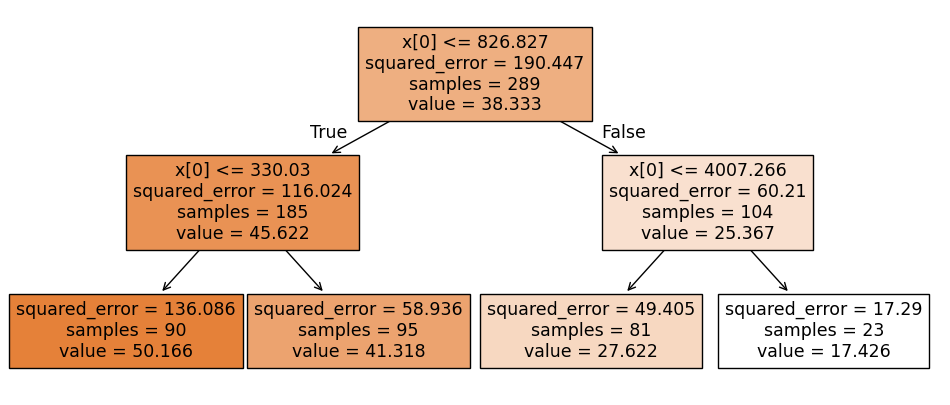

In [19]:
# APARTADO A)

from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

# Entrenamos el árbol. Se nos indica que debe ser necesario hacer dos
# preguntas, es decir, asignamos max_depth = 2
arbol = DecisionTreeRegressor(max_depth=2)
arbol.fit(X_ent, y_ent)

# Dibujamos el árbol para chequear que su profundidad máxima sea 2
fig = plt.figure(figsize=(12,5))
tree.plot_tree(arbol, filled = True)
plt.show()

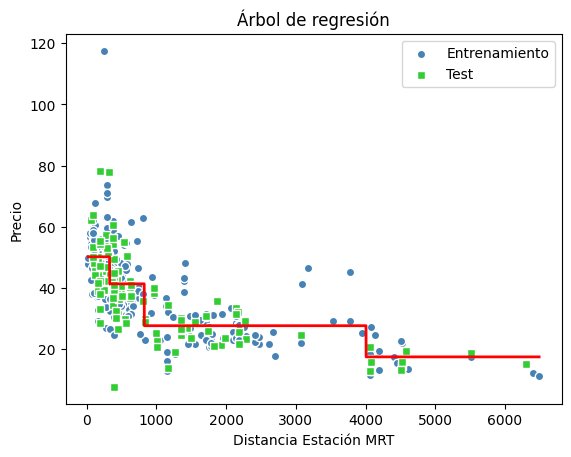

In [20]:
# APARTADO B)

# Pintamos las muestras

plt.scatter(X_ent, y_ent,
            c='steelblue', marker='o', edgecolor='white',
            label='Entrenamiento')
plt.scatter(X_test, y_test,
            c='limegreen', marker='s', edgecolor='white',
            label='Test')

# Para dibujar la recta a trozos es necesario calcular los puntos de todo el
# intervalo, no sólo el principio y el final como en algunos casos anteriores

XRango = np.arange(X.min(), X.max()+1, 1)
YRectaTrozosPred = arbol.predict(XRango[:, np.newaxis])

plt.plot(XRango, YRectaTrozosPred, color='red', lw=2)

plt.title('Árbol de regresión')
plt.xlabel('Distancia Estación MRT')
plt.ylabel('Precio')
plt.legend(loc = 'best')

plt.show()

In [21]:
# APARTADO C)

y_ent_pred = arbol.predict(X_ent)
y_test_pred = arbol.predict(X_test)

# Usamos scikit-learn metrics para calcular ECM y R^2

print('Error Cuadrático Medio (ECM): \n\tEntrenamiento = %.3f \n\tTest = %.3f' % (
        mean_squared_error(y_ent, y_ent_pred),
        mean_squared_error(y_test, y_test_pred)))

print('Coeficiente de determinación R^2: \n\tEntrenamiento = %.3f \n\tTest = %.3f' %
       (r2_score(y_ent, y_ent_pred), r2_score(y_test, y_test_pred)))

Error Cuadrático Medio (ECM): 
	Entrenamiento = 76.976 
	Test = 66.038
Coeficiente de determinación R^2: 
	Entrenamiento = 0.596 
	Test = 0.613


## Ejercicio Avanzado

5. Divida el conjunto de muestras “RealState.xlsx” en entrenamiento y test. Considere todos los pares de rasgos de entrada posibles (incluyendo los casos en los que un rasgo se empareja consigo mismo):

    **a)** Realice una regresión lineal múltiple y calcule el ECM y el coeficiente de determinación del modelo en entrenamiento y en test, para cada par de rasgos de entrada. Dibuje cuatro figuras mostrando los resultados mediante matrices con colores. Cada figura debe ser similar a ésta:


<div align="center">
        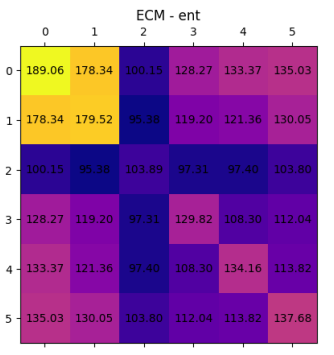
</div>

**b)** Explique en detalle y dando el razonamiento, qué pareja(s) de rasgos sería(n) más apropiada(s) para realizar la regresión en este conjunto de datos.

**c)** Con la pareja de rasgos seleccionada en el apartado anterior, haga una regresión lineal múltiple y genere una gráfica bidimensional en la que los ejes X y Y sean los rasgos seleccionados, y el color indique la variable predicha (el precio). Debe dibujar la estimación del regresor mediante una matriz coloreada, y las muestras de entrenamiento como una nube de puntos coloreados. Añada una barra de color para poder interpretar los colores como valores de la variable predicha. El resultado debe ser similar a éste:

<div align="center">
        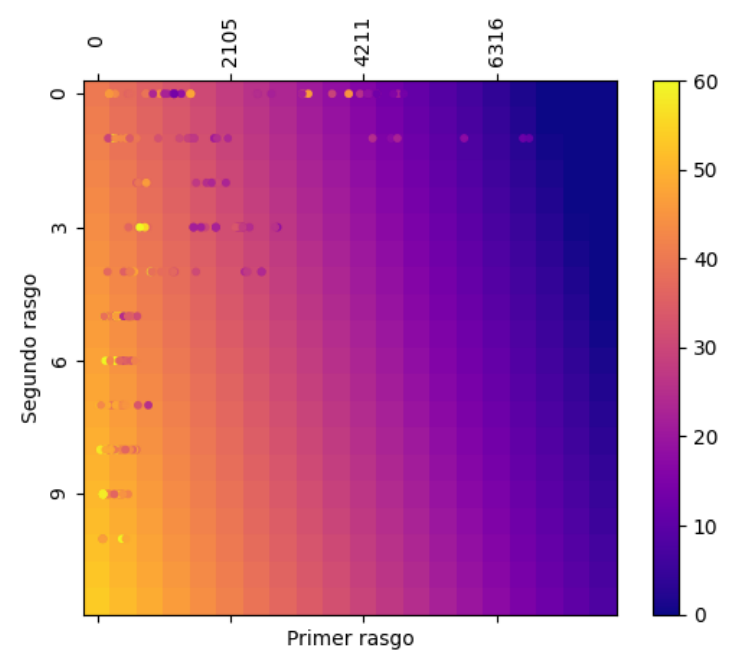
</div>

**d)** ¿Para qué valores de los dos rasgos de entrada se observa un mayor error? Explique y justifique su respuesta en detalle.

In [22]:
# División del conjunto de muestras en entrenamiento y test como ya
# venimos haciendo en el resto de prácticas

colElegidas = ['transaction_date', 'house_age', 'dst_near_MRT', 'num_store',
              'latitude', 'longitude']
X = df[colElegidas].values
y = df['house_price_unit_area'].values

X_ent, X_test, y_ent, y_test = train_test_split(X, y, test_size=0.3,
                                                random_state=0)

In [23]:
# APARTADO A)

# Vamos a definir las matrices que usaremos para guardar los datos de ECM y R^2
# en entrenamiento y test de cada pareja de rasgos usados

num_rasgos = X.shape[1]
matriz_ecm_ent = np.zeros((num_rasgos, num_rasgos))
matriz_ecm_test = np.zeros((num_rasgos, num_rasgos))
matriz_r2_ent = np.zeros((num_rasgos, num_rasgos))
matriz_r2_test = np.zeros((num_rasgos, num_rasgos))

# Iteramos para todas las parejas de rasgos y entrenamos un LR múltiple

for i in range(num_rasgos):
    for j in range(num_rasgos):

        X_ent_par = X_ent[:, [i, j]]
        X_test_par = X_test[:, [i, j]]

        modelo = LinearRegression()
        modelo.fit(X_ent_par, y_ent)

        y_ent_pred = modelo.predict(X_ent_par)
        y_test_pred = modelo.predict(X_test_par)

        # Calculamos ECM en entrenamiento y test
        matriz_ecm_ent[i, j] = mean_squared_error(y_ent, y_ent_pred)
        matriz_ecm_test[i, j] = mean_squared_error(y_test, y_test_pred)

        # Calculamos R^2 en entrenamiento y test
        matriz_r2_ent[i, j] = r2_score(y_ent, y_ent_pred)
        matriz_r2_test[i, j] = r2_score(y_test, y_test_pred)

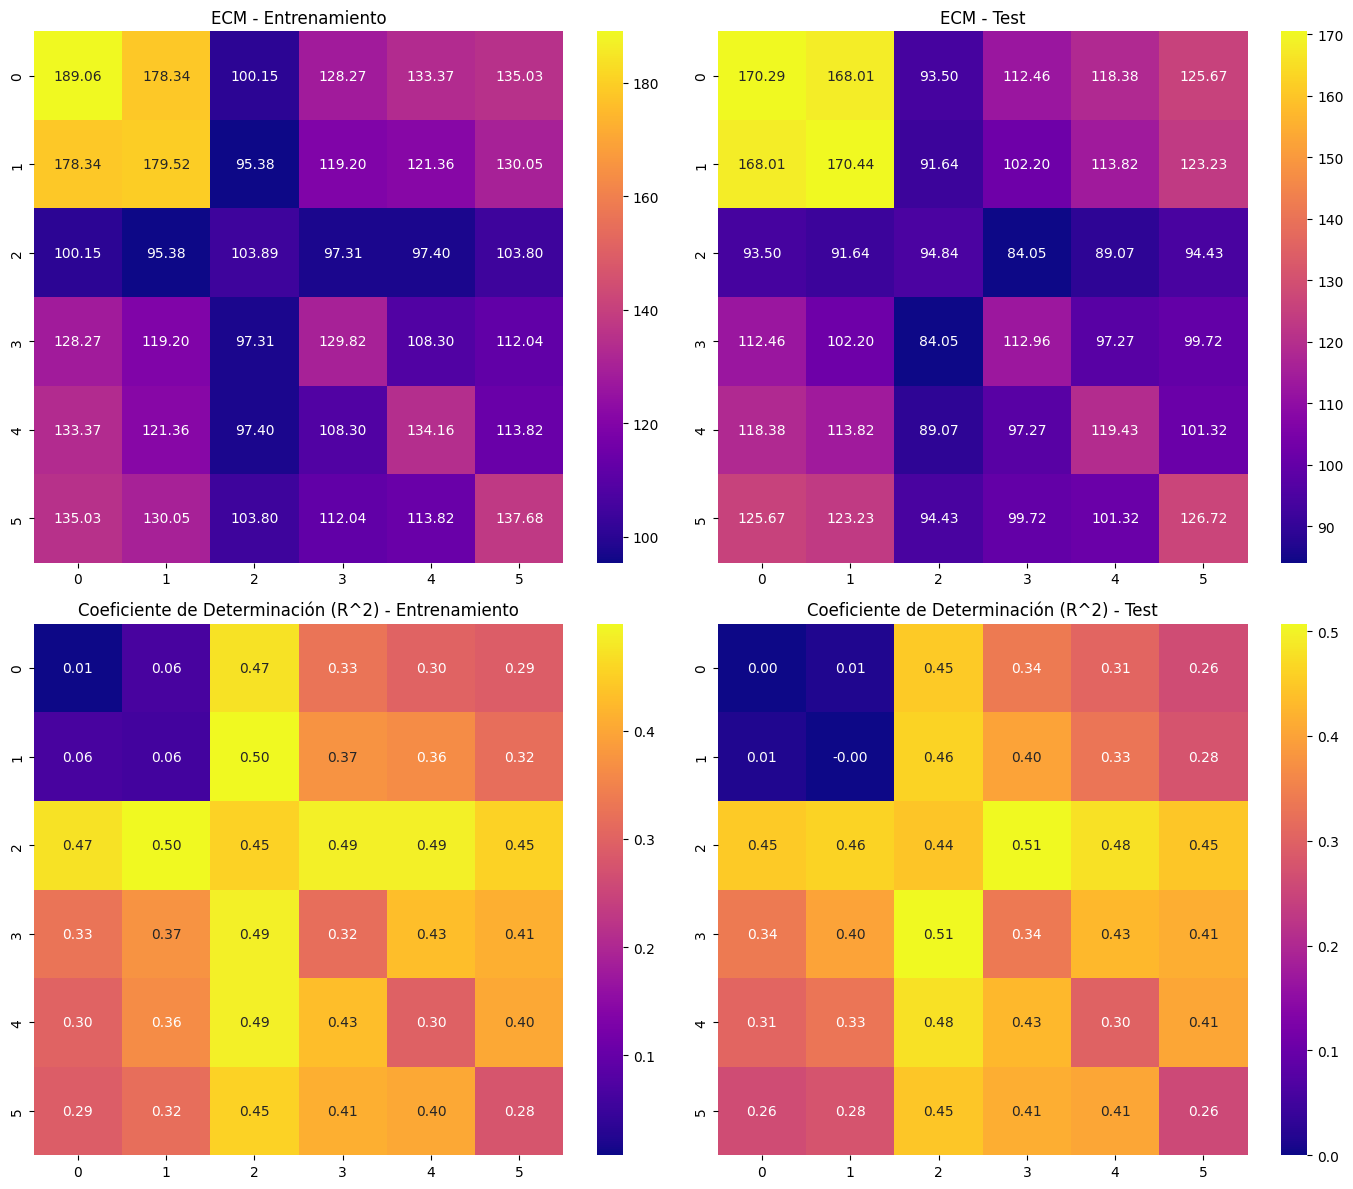

In [24]:
import seaborn as sns

# Graficamos los mapas de calor usando seaborn

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Mapa ECM Entrenamiento
sns.heatmap(matriz_ecm_ent, annot=True, fmt=".2f", cmap="plasma", ax=axes[0, 0])
axes[0, 0].set_title('ECM - Entrenamiento')

# Mapa ECM Test
sns.heatmap(matriz_ecm_test, annot=True, fmt=".2f", cmap="plasma", ax=axes[0, 1])
axes[0, 1].set_title('ECM - Test')

# Mapa R2 Entrenamiento
sns.heatmap(matriz_r2_ent, annot=True, fmt=".2f", cmap="plasma", ax=axes[1, 0])
axes[1, 0].set_title('Coeficiente de Determinación (R^2) - Entrenamiento')

# Mapa R2 Test
sns.heatmap(matriz_r2_test, annot=True, fmt=".2f", cmap="plasma", ax=axes[1, 1])
axes[1, 1].set_title('Coeficiente de Determinación (R^2) - Test')

plt.tight_layout()
plt.show()

**APARTADO B)**

Fijándonos en las figuras de test, buscamos un valor cercano a 0 en ECM y un valor cercano a 1 en R^2. De esta forma, la pareja de rasgos **'dst_near_MRT' - 'num_store'** alcanza un coeficiente de determinación de 0.51 y un ECM de 84.05.

Esto tiene sentido ya que una zona cercana al metro normalmente tiene muchas tiendas cercanas a su vez. Ya vimos que estos eran los rasgos más relacionados con el precio de la vivienda.

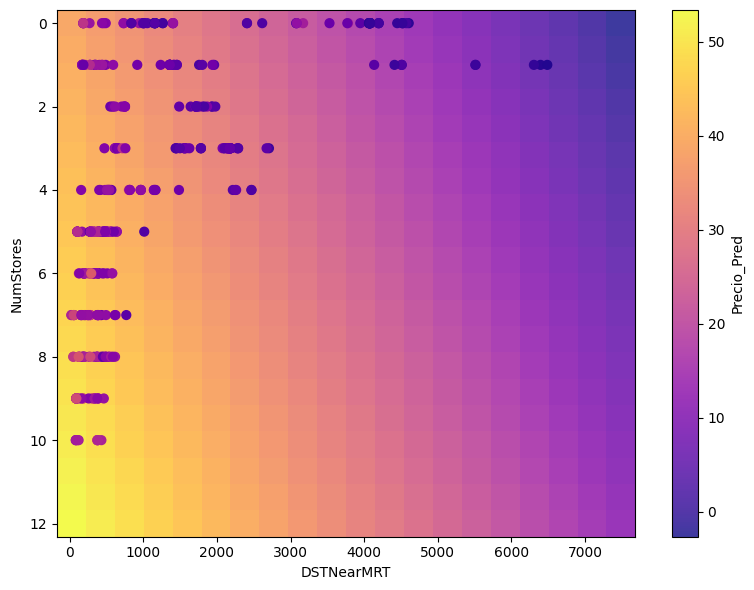

In [25]:
# APARTADO C)

# Seleccionamos los mejores rasgos anteriores

X = df[['dst_near_MRT','num_store']].values
y = df['house_price_unit_area'].values

# Estandarizamos los rasgos

# Entrenamos
regLin = LinearRegression()
regLin.fit(X, y)

# Eje X en el gráfico -> distancia a la estación MRT más cercana
# Eje Y en el gráfico -> numero de tiendas
# Eje Z en el gráfico -> precio predicho

dst_near_MRT = X[:,0]
num_store = X[:,1]
precio = y

# Crear una malla de valores para los ejes X (dst_near_MRT) e Y (num_store)
x1_min, x1_max = dst_near_MRT.min(), dst_near_MRT.max()
x2_min, x2_max = num_store.min(), num_store.max()
x1_rango = np.linspace(x1_min, x1_max + 1000, 20)
x2_rango = np.linspace(x2_min, x2_max + 2, 20)
xx1, xx2 = np.meshgrid(x1_rango, x2_rango)
malla_patrones = np.column_stack((xx1.ravel(), xx2.ravel()))

# Realizar predicciones en la malla de predicciones
malla_predicciones = regLin.predict(malla_patrones)
malla_predicciones = malla_predicciones.reshape(xx1.shape)

fig = plt.figure(figsize=(8, 6))

fondo = plt.pcolormesh(xx1, xx2, malla_predicciones,
                       alpha=0.8, cmap = 'plasma')

# Nube de puntos
plt.scatter(dst_near_MRT, num_store, c=precio, cmap='plasma', s=40)

# Barra de color
barra = plt.colorbar(fondo)
barra.set_label('Precio_Pred')

plt.xlabel('DSTNearMRT')
plt.ylabel('NumStores')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**APARTADO D)**

El mayor error se da en los **extremos** de la **distancia a la estación MRT**. A distancias muy cortas, el precio real se dispara, por lo que el modelo lineal lo subestima. A distancias muy largas, existe un precio mínimo de mercado que el modelo ignora, provocando que sobreestime el valor al forzar una caída constante.

## Ejercicio Experto

6. Divida el conjunto de muestras “RealState.xlsx” en entrenamiento y test. Considere todos los rasgos de entrada:

    **a)** Entrene un árbol de regresión para valores del hiperparámetro max_depth entre 1 y 6, ambos inclusive. Calcule el ECM y el coeficiente de determinación del modelo en entrenamiento y en test. Dibuje dos figuras, una para el ECM y otra para el coeficiente de determinación. En cada figura debe mostrar una serie de datos para el rendimiento en entrenamiento, y otra serie de datos para el rendimiento en test. El eje horizontal será el valor del hiperparámetro, y el eje vertical el valor de la medida de rendimiento.

    **b)** Explique en detalle y dando el razonamiento, qué valor(es) del hiperparámetro max_depth sería(n) más apropiado(s) para realizar la regresión en este conjunto de datos.

    **c)** Entrene un árbol de regresión para valores del hiperparámetro min_samples_leaf entre 0.01 y 0.99, ambos inclusive. Calcule el ECM y el coeficiente de determinación del modelo en entrenamiento y en test. Dibuje dos figuras, una para el ECM y otra para el coeficiente de determinación. En cada figura debe mostrar una serie de datos para el rendimiento en entrenamiento, y otra serie de datos para el rendimiento en test. El eje horizontal será el valor del hiperparámetro, y el eje vertical el valor de la medida de rendimiento.

    **d)** Explique en detalle y dando el razonamiento, qué valor(es) del hiperparámetro min_samples_leaf sería(n) más apropiado(s) para realizar la regresión en este conjunto de datos.

In [26]:
# División del conjunto de muestras en entrenamiento y test como ya
# venimos haciendo en el resto de prácticas

colElegidas = ['transaction_date', 'house_age', 'dst_near_MRT', 'num_store',
              'latitude', 'longitude']
X = df[colElegidas].values
y = df['house_price_unit_area'].values

X_ent, X_test, y_ent, y_test = train_test_split(X, y, test_size=0.3,
                                                random_state=0)

In [27]:
# APARTADO A)

# Rango de valores del hiperparámetro max_depth
profundidades = range(1, 7)

# Definimos listas donde guardaremos las métricas ECM y R^2
# de entrenamiento y test para cada profundidad

ecm_ent = []
ecm_test = []
r2_ent = []
r2_test = []

for depth in profundidades:

    arbol = DecisionTreeRegressor(max_depth=depth, random_state=0)
    arbol.fit(X_ent, y_ent)

    y_ent_pred = arbol.predict(X_ent)
    y_test_pred = arbol.predict(X_test)

    # Calculamos y guardamos el ECM
    ecm_ent.append(mean_squared_error(y_ent, y_ent_pred))
    ecm_test.append(mean_squared_error(y_test, y_test_pred))

    # Calculamos y guardamos el coeficiente R^2
    r2_ent.append(r2_score(y_ent, y_ent_pred))
    r2_test.append(r2_score(y_test, y_test_pred))

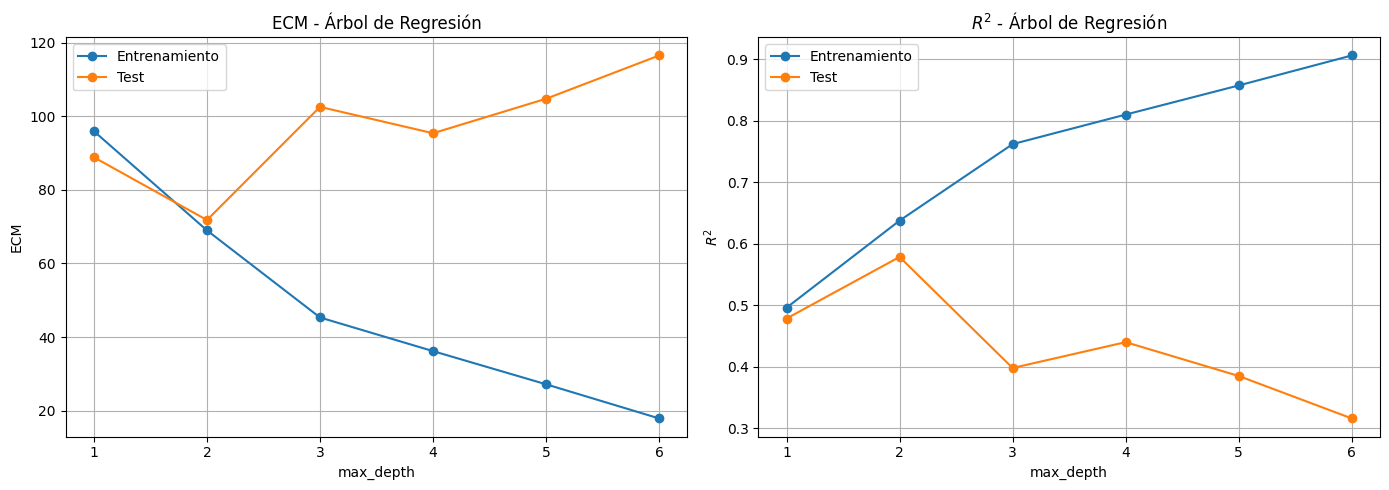

In [28]:
# Pintamos ambas gráficas

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(profundidades, ecm_ent, marker='o', label='Entrenamiento')
ax1.plot(profundidades, ecm_test, marker='o', label='Test')
ax1.set_xlabel('max_depth')
ax1.set_ylabel('ECM')
ax1.set_title('ECM - Árbol de Regresión')
ax1.set_xticks(profundidades)
ax1.legend()
ax1.grid(True)

ax2.plot(profundidades, r2_ent, marker='o', label='Entrenamiento')
ax2.plot(profundidades, r2_test, marker='o', label='Test')
ax2.set_xlabel('max_depth')
ax2.set_ylabel('$R^2$')
ax2.set_title('$R^2$ - Árbol de Regresión')
ax2.set_xticks(profundidades)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**APARTADO B)**

El valor de **max_depth** igual a **2** creo que sería el mejor valor ya que a partir de ese momento, el aumento de profundidad implica una gran pérdida de rendimiento.

In [29]:
# APARTADO C)

# Rango de valores del hiperparámetro min_samples_leaf
num_hojas = np.arange(0.01, 1, 0.01)

# Definimos listas donde guardaremos las métricas ECM y R^2
# de entrenamiento y test para cada profundidad

ecm_ent = []
ecm_test = []
r2_ent = []
r2_test = []

for leafs in num_hojas:

    arbol = DecisionTreeRegressor(min_samples_leaf=leafs, random_state=0)
    arbol.fit(X_ent, y_ent)

    y_ent_pred = arbol.predict(X_ent)
    y_test_pred = arbol.predict(X_test)

    # Calculamos y guardamos el ECM
    ecm_ent.append(mean_squared_error(y_ent, y_ent_pred))
    ecm_test.append(mean_squared_error(y_test, y_test_pred))

    # Calculamos y guardamos el coeficiente R^2
    r2_ent.append(r2_score(y_ent, y_ent_pred))
    r2_test.append(r2_score(y_test, y_test_pred))

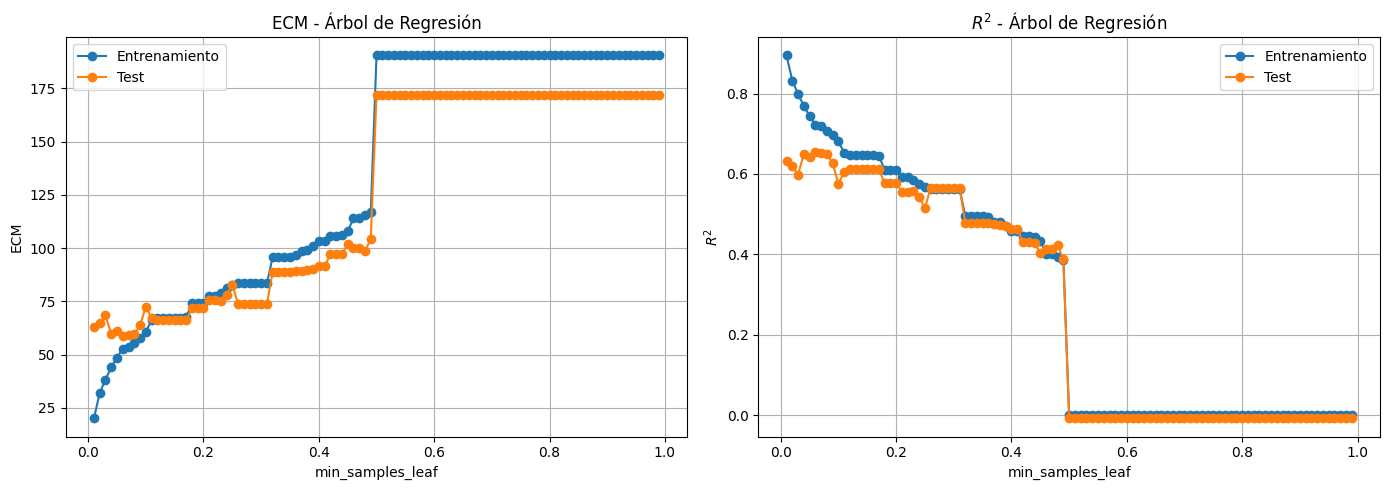

In [30]:
# Pintamos ambas gráficas

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(num_hojas, ecm_ent, marker='o', label='Entrenamiento')
ax1.plot(num_hojas, ecm_test, marker='o', label='Test')
ax1.set_xlabel('min_samples_leaf')
ax1.set_ylabel('ECM')
ax1.set_title('ECM - Árbol de Regresión')
ax1.legend()
ax1.grid(True)

ax2.plot(num_hojas, r2_ent, marker='o', label='Entrenamiento')
ax2.plot(num_hojas, r2_test, marker='o', label='Test')
ax2.set_xlabel('min_samples_leaf')
ax2.set_ylabel('$R^2$')
ax2.set_title('$R^2$ - Árbol de Regresión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**APARTADO D)**

El valor de **min_samples_leafs** entre **0.1 y 0.2** sería el más apropiado ya que a partir de ese momento el ECM se dispara (y obviamente el coeficiente de determinación se vuelve 0).